In [53]:
# !pip install mlxtend
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from datetime import datetime, timedelta
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_auc_score, roc_curve,
                             mean_squared_error, r2_score, silhouette_score, davies_bouldin_score,mean_absolute_error)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder



import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [31]:
df = pd.read_csv('Air_Quality_Measures_on_the_National_Environmental_Health_Tracking_Network (1).csv')
df 

,MeasureId,MeasureName,MeasureType,StratificationLevel,StateFips,StateName,CountyFips,CountyName,ReportYear,Value,Unit,UnitName,DataOrigin,MonitorOnly
0,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1027,Clay,1999,33.000000,No Units,No Units,Monitor Only,1
1,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1051,Elmore,1999,5.000000,No Units,No Units,Monitor Only,1
2,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1073,Jefferson,1999,39.000000,No Units,No Units,Monitor Only,1
3,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1079,Lawrence,1999,28.000000,No Units,No Units,Monitor Only,1
4,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1089,Madison,1999,31.000000,No Units,No Units,Monitor Only,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218630,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2007,6.207126,µg/m³,Micograms per cubic meter,Monitor & Modeled,0
218631,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2008,6.369764,µg/m³,Micograms per cubic meter,Monitor & Modeled,0
218632,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2009,6.241708,µg/m³,Micograms per cubic meter,Monitor & Modeled,0
218633,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2010,6.125957,µg/m³,Micograms per cubic meter,Monitor & Modeled,0


In [3]:
print(df.isnull().sum())

MeasureId              0
MeasureName            0
MeasureType            0
StratificationLevel    0
StateFips              0
StateName              0
CountyFips             0
CountyName             0
ReportYear             0
Value                  0
Unit                   0
UnitName               0
DataOrigin             0
MonitorOnly            0
dtype: int64


In [32]:
if 'Value' in df.columns:
    scaler = MinMaxScaler()
    df['Value_scaled'] = scaler.fit_transform(df[['Value']])

In [33]:
categorical_columns = ['StateName', 'CountyName']  # Adjust based on your dataset
for col in categorical_columns:
    if col in df.columns:
        df = pd.get_dummies(df, columns=[col], drop_first=True)

In [34]:
df = df[df['ReportYear'] > 2000]

In [35]:
df = df[df['StateName_California'] == 1]

In [36]:
treated = df[df['MonitorOnly'] == 1]
control = df[df['MonitorOnly'] == 0]

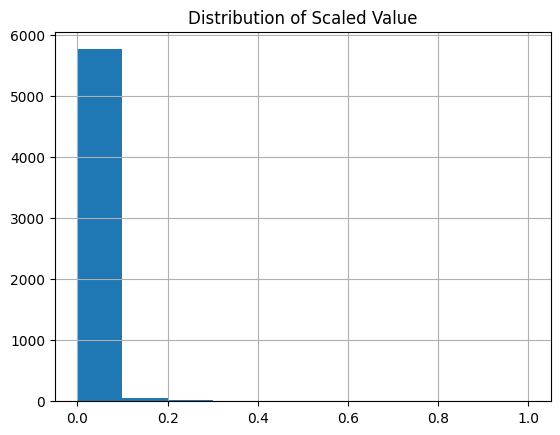

In [37]:
df['Value_scaled'].hist()
plt.title('Distribution of Scaled Value')
plt.show()

In [271]:
df = pd.read_csv('separated_measures\pm25_concentration_monitor.csv')
df


<>:1: DeprecationWarning: invalid escape sequence '\p'
<>:1: DeprecationWarning: invalid escape sequence '\p'
C:\Users\shuga\AppData\Local\Temp\ipykernel_25548\3533917233.py:1: DeprecationWarning: invalid escape sequence '\p'
  df = pd.read_csv('separated_measures\pm25_concentration_monitor.csv')


,MeasureId,MeasureType,StratificationLevel,StateFips,StateName,CountyFips,CountyName,ReportYear,Value,Unit,UnitName,DataOrigin,MonitorOnly,MeasureKey
0,87,Average,State x County,54,West Virginia,54081,Raleigh,2003,12.349080,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
1,87,Average,State x County,12,Florida,12033,Escambia,2002,10.953455,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
2,87,Average,State x County,29,Missouri,29099,Jefferson,1999,15.155819,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
3,87,Average,State x County,30,Montana,30029,Flathead,2001,8.272648,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
4,87,Average,State x County,12,Florida,12103,Pinellas,2006,9.553561,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8417,87,Average,State x County,35,New Mexico,35049,Santa Fe,2000,5.217125,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
8418,87,Average,State x County,40,Oklahoma,40135,Sequoyah,2005,14.118101,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
8419,87,Average,State x County,33,New Hampshire,33011,Hillsborough,2001,10.826305,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
8420,87,Average,State x County,49,Utah,49035,Salt Lake,2010,10.954182,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor


In [272]:
df = df.drop(['MeasureId','StateName', 'MeasureType', 'StratificationLevel','Unit','UnitName','CountyName','DataOrigin'	,'MonitorOnly'	,'MeasureKey'],axis=1)

In [273]:
df 

,StateFips,CountyFips,ReportYear,Value
0,54,54081,2003,12.349080
1,12,12033,2002,10.953455
2,29,29099,1999,15.155819
3,30,30029,2001,8.272648
4,12,12103,2006,9.553561
...,...,...,...,...
8417,35,35049,2000,5.217125
8418,40,40135,2005,14.118101
8419,33,33011,2001,10.826305
8420,49,49035,2010,10.954182


In [13]:
def categorize_aqi(value):
    """Categorize air quality based on number of exceedance days"""
    if value <= 10:
        return 'Good'
    elif value <= 25:
        return 'Moderate'
    elif value <= 50:
        return 'Unhealthy for Sensitive'
    elif value <= 75:
        return 'Unhealthy'
    else:
        return 'Very Unhealthy'

df['AQI_Category'] = df['Value'].apply(categorize_aqi)

In [16]:
le_state = LabelEncoder()
le_county = LabelEncoder()
# df['State_Encoded'] = le_state.fit_transform(df['StateName'])
# df['County_Encoded'] = le_county.fit_transform(df['CountyName'])
# df = df.drop(['StateName'],axis=1)

In [17]:
scaler = MinMaxScaler()
df['Value_scaled'] = scaler.fit_transform(df[['Value']])
df = df.drop(['Value'],axis=1)

In [25]:
X = df.drop(["Value"],axis=1)
y = df['Value']

In [26]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [27]:
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

regression_results = {}

In [28]:
lr_model = LinearRegression()
lr_model.fit(X_train_reg_scaled, y_train_reg)
y_pred_lr = lr_model.predict(X_test_reg_scaled)

In [29]:
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)
mae_lr = np.mean(np.abs(y_test_reg - y_pred_lr))

print(f"MSE (Mean Squared Error):     {mse_lr:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse_lr:.4f}")
print(f"R² Score:                       {r2_lr:.4f}")
print(f"MAE (Mean Absolute Error):      {mae_lr:.4f}")

MSE (Mean Squared Error):     8.0129
RMSE (Root Mean Squared Error): 2.8307
R² Score:                       0.2074
MAE (Mean Absolute Error):      2.1632


In [89]:
features = ["StateFips","CountyFips",	"ReportYear",	"Value","State_Encoded"]
for feat, coef in zip(features, lr_model.coef_):
    print(f"   {feat}: {coef:.4f}")
print(f"   Intercept: {lr_model.intercept_:.4f}")

   StateFips: -0.1840
   CountyFips: 0.1798
   ReportYear: -0.0497
   Intercept: 0.0555


In [107]:
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_model = Ridge()
ridge_grid = GridSearchCV(ridge_model, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_reg_scaled, y_train_reg)

ridge_best = ridge_grid.best_estimator_
y_pred_ridge = ridge_best.predict(X_test_reg_scaled)


In [105]:
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
mae_ridge = np.mean(np.abs(y_test_reg - y_pred_ridge))

In [108]:
print(f"MSE:  {mse_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R² Score: {r2_ridge:.4f}")
print(f"MAE:  {mae_ridge:.4f}")

MSE:  0.0033
RMSE: 0.0571
R² Score: 0.2074
MAE:  0.0436


In [109]:
rf_reg_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_reg_model = RandomForestRegressor(random_state=42)
rf_reg_grid = GridSearchCV(rf_reg_model, rf_reg_params, cv=3, scoring='r2', n_jobs=-1)
rf_reg_grid.fit(X_train_reg, y_train_reg)

print(f"   Best Parameters: {rf_reg_grid.best_params_}")
print(f"   Best CV Score: {rf_reg_grid.best_score_:.4f}")

rf_reg_best = rf_reg_grid.best_estimator_
y_pred_rf_reg = rf_reg_best.predict(X_test_reg)



   Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
   Best CV Score: 0.6743


In [110]:

mse_rf_reg = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)
mae_rf_reg = np.mean(np.abs(y_test_reg - y_pred_rf_reg))

print(f"MSE:  {mse_rf_reg:.4f}")
print(f"RMSE: {rmse_rf_reg:.4f}")
print(f"R² Score: {r2_rf_reg:.4f}")
print(f"MAE:  {mae_rf_reg:.4f}")

MSE:  0.0010
RMSE: 0.0320
R² Score: 0.7511
MAE:  0.0218


In [38]:
from statsmodels.formula.api import ols

model = ols('Value_scaled ~ MonitorOnly + ReportYear', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Value_scaled   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     15.97
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           1.21e-07
Time:                        02:50:42   Log-Likelihood:                 8327.2
No. Observations:                5873   AIC:                        -1.665e+04
Df Residuals:                    5870   BIC:                        -1.663e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.2677      0.447      2.833      

### Time Series model: LSTM 

In [274]:

df_sorted = df.sort_values(['StateFips', 'CountyFips', 'ReportYear']).reset_index(drop=True)
df_sorted

,StateFips,CountyFips,ReportYear,Value
0,1,1003,2000,14.528161
1,1,1003,2001,10.579318
2,1,1003,2002,10.370667
3,1,1003,2003,12.167529
4,1,1003,2004,11.356519
...,...,...,...,...
8417,56,56039,2009,4.668711
8418,56,56039,2010,4.330644
8419,56,56039,2011,4.568457
8420,56,56039,2012,6.282592


In [282]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_sorted[['Value']])

In [283]:
def prepare_lstm_data(data, lookback=5):
    """
    Prepare data for LSTM model
    lookback: number of previous timesteps to use as input variables
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 5
X, y = prepare_lstm_data(scaled_data, lookback=lookback)

# Reshape X for LSTM [samples, timesteps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)


In [284]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [285]:
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])



d:\Data Mining_assigments\Air-Quality-Index-Data-Mining-Project-\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [286]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 5, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 5, 50)          │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,101 (203.52 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 0 (0.00 B)

In [287]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50


d:\Data Mining_assigments\Air-Quality-Index-Data-Mining-Project-\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\Data Mining_assigments\Air-Quality-Index-Data-Mining-Project-\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


159/169 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0083

d:\Data Mining_assigments\Air-Quality-Index-Data-Mining-Project-\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0046 - val_loss: 0.0024
Epoch 2/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 3/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0025 - val_loss: 0.0017
Epoch 4/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 5/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 6/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 7/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0022 - val_loss: 0.0014
Epoch 8/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 9/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 10/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 11/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0020 - val_loss: 0.0014
Epoch 12/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.

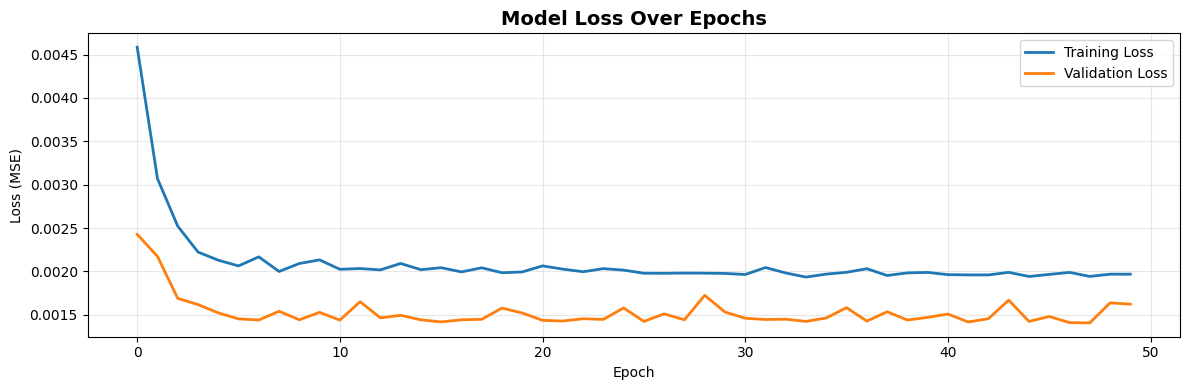

In [288]:
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

axes.plot(history.history['loss'], label='Training Loss', linewidth=2)
axes.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes.set_xlabel('Epoch')
axes.set_ylabel('Loss (MSE)')
axes.legend()
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [289]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [290]:
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_train_pred = scaler.inverse_transform(y_train_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_pred = scaler.inverse_transform(y_test_pred)

In [291]:
train_rmse = np.sqrt(mean_squared_error(y_train_actual, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
train_mae = mean_absolute_error(y_train_actual, y_train_pred)
test_mae = mean_absolute_error(y_test_actual, y_test_pred)


In [292]:
y_train_pred = y_train_pred - 1

y_train_pred

array([[ 9.809019],
       [10.036998],
       [ 9.769144],
       ...,
       [10.28162 ],
       [10.901816],
       [10.42419 ]], shape=(6733, 1), dtype=float32)

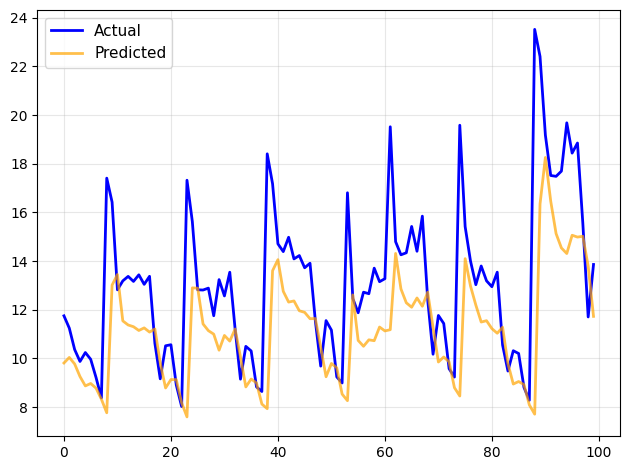

In [293]:
# fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Training performance
plt.plot(y_train_actual[:100], label='Actual', linewidth=2, color='blue')
plt.plot(y_train_pred[:100], label='Predicted', linewidth=2, alpha=0.7, color='orange')
# plt.set_title(' Actual vs Predicted', fontsize=14, fontweight='bold')
# plt.set_xlabel('Sample')
# plt.set_ylabel('Value')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()